In [1]:
#!/usr/bin/python
# -*- coding: utf-8 -*-

import numpy as np
import cmath
import seaborn
import matplotlib.pyplot as plt
import stingray as sg
from stingray.modeling import PSDParEst
from stingray import Lightcurve, Powerspectrum, Crossspectrum, AveragedCrossspectrum, AveragedPowerspectrum
from stingray.simulator import simulator, models
import astropy.io.fits as pyfits
import os
import statistics
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from astropy.modeling import models
import ndspec
pi = np.pi

sign_char = lambda x: '+' if x > 0 else '-'

#
def make_decaying_sine(constant, factor, nu, Dnu, phi, t, kick=False, kick_period = 0.2, phase=0):
    """Decaying sine-wave"""
    alpha = np.pi * Dnu
    if kick == False:
        return constant + factor*constant*np.exp(-alpha * np.abs(t)) * np.sin(2*np.pi*nu*t - 2*np.pi*phi + phase)
    else:
        total_kicks = np.max(t) // kick_period + 1
        time_scatter_per_kick = np.random.normal(1, 0.1, int(total_kicks)) * kick_period
        print(time_scatter_per_kick, total_kicks)
        time = []
        i = 0
        j = 0
        t_i = t[i]
        kick_j = time_scatter_per_kick[j]
        while t_i < np.max(t):
            time_block = constant + factor*constant*np.exp(-alpha * np.abs(t_i%kick_j)) * np.sin(2*np.pi*nu*(t_i%kick_j) - 2*np.pi*phi)
            print(time_block)
            time.append(time_block)
            i += 1
            if t[i] >= sum(time_scatter_per_kick[:j]):
                j += 1
            t_i = t[i]
            if j >= len(time_scatter_per_kick):
                break
            else:
                kick_j = time_scatter_per_kick[j]
        return np.array(time)

def sine_wave_distort(x1, x2, constant):
    """Distort a sine wave by a power law."""
    return constant*(x1 + x2)

#
def gen_noise(x, dt=0.125, rms=1.0, beta=2):
    """Adding some noise à la Timmer & Koenig"""

    sim = simulator.Simulator(N=len(x), mean=10, dt=dt, rms=rms)
    lc = sim.simulate(beta)
    return lc + x

def gen_noise_original(time, x, fmin=1e-3, fmax=1e2, nfreq=1e2, beta=1.0, norm=1):
    """Adding some noise à la Timmer & Koenig"""

    freqs = 10**((np.log10(fmax) - np.log10(fmin)) *  np.linspace(0, 1, int(nfreq)) + np.log10(fmin))

    lc0 = np.mean(x)
    lc = x - lc0

    for ifreq,freq in enumerate(freqs):
        #print(np.round(ifreq/nfreq,2)*100)
        print(norm * (1./freq)**beta * np.cos(2*np.pi*freq*time - np.random.rand()*2*np.pi) / nfreq)
        lc += norm * (1./freq)**beta * np.cos(2*np.pi*freq*time - np.random.rand()*2*np.pi) / nfreq

    return lc - np.mean(lc) + lc0

def plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower,x_lim_upper,file = "figures/decaying_sine_wave.png",omega3=None):
    """
    Plots results

    Parameters
    -----------
    t_plot : array
        Time array for the plot.
    x1_noise : Lightcurve
        Lightcurve object for the first signal with noise.
    x2_noise : Lightcurve
        Lightcurve object for the second signal with noise.
    ps1 : Powerspectrum
        Power spectrum object for the first signal.
    ps2 : Powerspectrum
        Power spectrum object for the second signal.
    omega1 : float
        Frequency of the first signal.
    omega2 : float
        Frequency of the second signal.
    cs12 : Crossspectrum
        Cross spectrum object between the two signals.
    avgcs12 : AveragedCrossspectrum
        Averaged cross spectrum object between the two signals.
    x_lim_lower : float
        Lower limit for the x-axis.
    x_lim_upper : float
        Upper limit for the x-axis.

    """
    fig = plt.figure(figsize=(18, 8))

    ax1=plt.subplot(2,1,1)
    ax1.plot(t_plot, x1_noise.counts, c="#e66101", label=r"$\phi_1$")
    ax1.plot(t_plot, x2_noise.counts, c="#5e3c99", label=r"$\phi_2$")
    ax1.set_xlabel('Time (s)')
    ax1.legend()
    ax1.set_ylabel('Amplitude')
    ax1.set_xlim(0,5)

    ax2=plt.subplot(2,4,5)
    ax2.plot(ps1.freq, ps1.freq*ps1.power, c="#e66101",label=r"$\phi_1$ PSD")
    ax2.plot(ps2.freq, ps2.freq*ps2.power, c="#5e3c99",label=r"$\phi_2$ PSD")
    ax2.axvline(omega1, color="#b2abd2", linestyle='--')
    ax2.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax2.axvline(omega3, color="#b2abd2", linestyle='--')
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.legend(loc="lower left")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel(r"Frequency * Power (rms$^2$)")
    ax2.set_ylim(1e-8, 1e-1)
    ax2.set_xlim(x_lim_lower, x_lim_upper)

    ax3=plt.subplot(2,4,6)
    ax3.plot(avgcs12.freq, np.real(avgcs12.power), c="#e66101",label="Real")
    ax3.plot(avgcs12.freq, np.imag(avgcs12.power), c="#5e3c99",label="Imaginary")
    ax3.axvline(omega1, color="#b2abd2", linestyle='--')
    ax3.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax3.axvline(omega3, color="#b2abd2", linestyle='--')
    ax3.set_yscale('symlog',linthresh=1e-4)
    ax3.set_xscale("log")
    ax3.set_ylabel('Cross-spectrum')
    ax3.legend()
    #ax3.set_ylim(-1e5, 1e6)
    ax3.set_xlim(x_lim_lower, x_lim_upper)
    ax3.set_xlabel("Frequency (Hz)")

    ax4 = plt.subplot(2,4,7)
    ax4.plot(avgcs12.freq, np.angle(avgcs12.power), c="#fdb863", label=r"$\phi_1/\phi_2$")
    ax4.axvline(omega1, color="#b2abd2", linestyle='--')
    ax4.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax4.axvline(omega3, color="#b2abd2", linestyle='--')
    ax4.set_xscale("log")
    ax4.set_ylabel('Phase (radians)')
    ax4.set_xlabel("Frequency (Hz)")
    ax4.set_xlim(x_lim_lower, x_lim_upper)
    ax4.set_ylim(-1, 1)
    #ax4.legend()

    ax5 = plt.subplot(2,4,8)
    ax5.plot(avgcs12.freq, avgcs12.coherence()[0], c="#fdb863", label=r"$\phi_1/\phi_2$")
    ax5.axvline(omega1, color="#b2abd2", linestyle='--')
    ax5.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax5.axvline(omega3, color="#b2abd2", linestyle='--')
    ax5.set_xscale("log")
    ax5.set_ylabel('Coherence')
    ax5.set_xlabel("Frequency (Hz)")
    ax5.set_ylim(0.75, 1.01)
    ax5.set_xlim(x_lim_lower, x_lim_upper)
    #ax5.legend()

    plt.tight_layout()
    plt.savefig(file)
    plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


# Basic simple signal case

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
10it [00:00, 2187.61it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


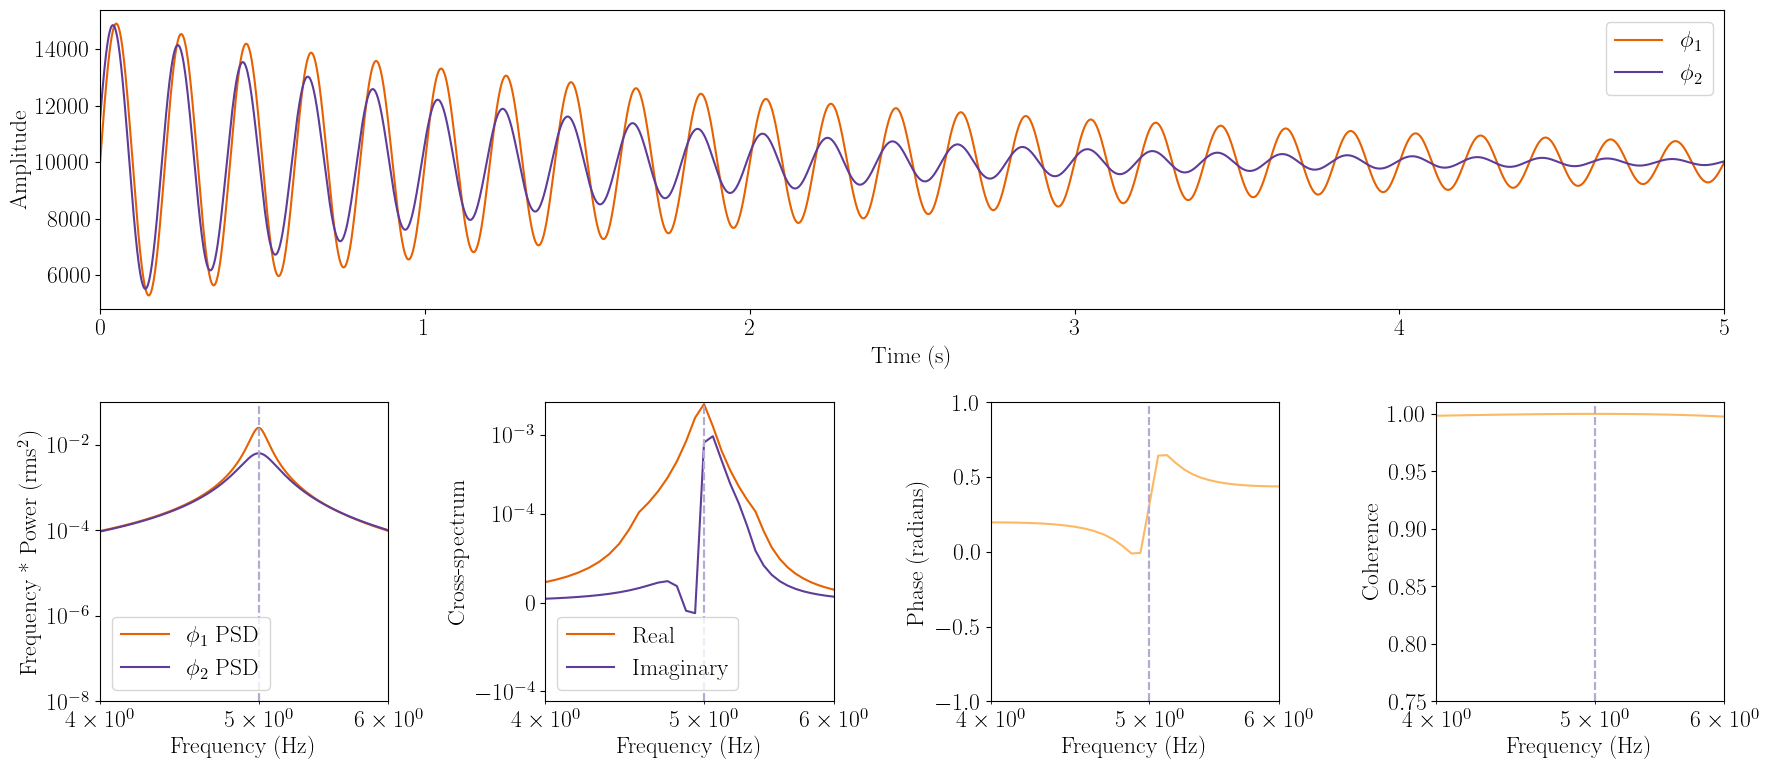

In [2]:
##
dt = 1e-3
T = 16*10
index = int(T/dt)
t = np.arange(-T, T, dt)
t_plot = t[index:]

constant = 10000
omega1 = 5.0
omega2 = 5.0
dampen1 = 0.25/2
dampen2 = 0.5/2

x1 = make_decaying_sine(constant, 0.5, omega1, dampen1, 0, t, kick=False, kick_period=5)
x2 = make_decaying_sine(constant, 0.5, omega2, dampen2, 0, t, kick=False, kick_period=5,phase = 0.1*np.pi)
#x3 = x1 + x2
x3 = sine_wave_distort(x1,x2,0.5)
lc1 = Lightcurve(t[index:], x1[index:])
lc2 = Lightcurve(t[index:], x2[index:])
x1_noise = lc1
x2_noise = lc2
#x1_noise.counts = gen_noise_original(lc1.time,lc1.counts,beta=0.1,norm=1000)
#x2_noise.counts = gen_noise_original(lc2.time,lc2.counts,beta=0.1,norm=1000)
#x1_noise.counts = np.random.poisson(x1_noise.counts)
#x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = Powerspectrum.from_lightcurve(lc1, norm="frac")
ps2 = Powerspectrum.from_lightcurve(lc2, norm="frac")

cs12 = Crossspectrum.from_lightcurve(lc1, lc2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, segment_size=16, norm="frac")

plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=4,x_lim_upper=6,file="figures/simple_decaying_sine_wave.png")


# Poisson noise case

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
10it [00:00, 3099.09it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)
/opt/miniconda3/envs/work/lib/python3.13/site-package

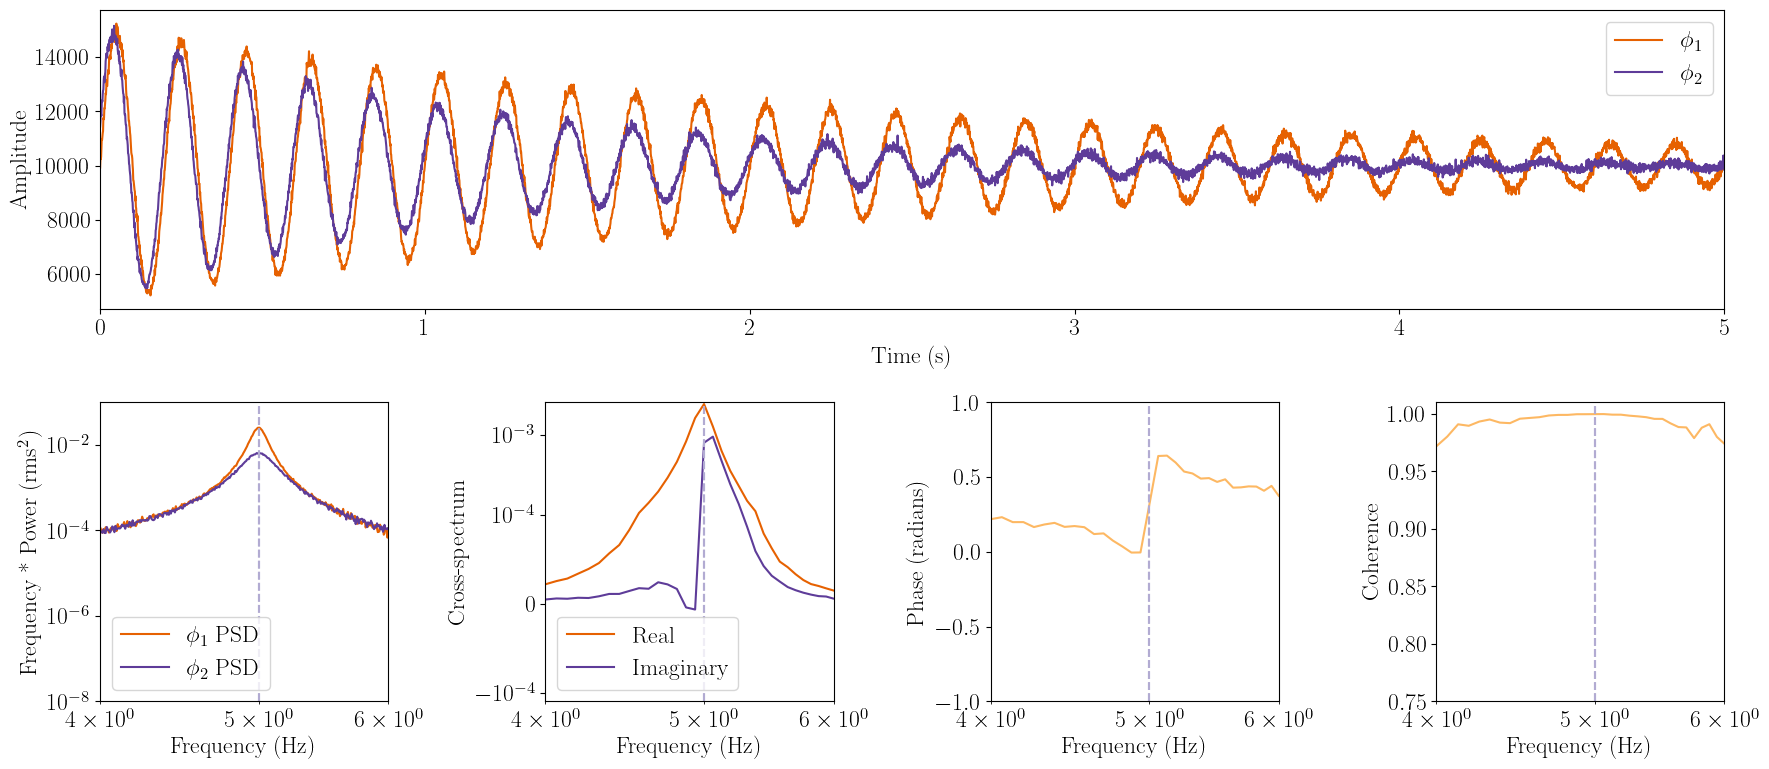

In [3]:
##
dt = 1e-3
T = 16*10
index = int(T/dt)
t = np.arange(-T, T, dt)
t_plot = t[index:]

constant = 10000
omega1 = 5.0
omega2 = 5.0
dampen1 = 0.25/2
dampen2 = 0.5/2

x1 = make_decaying_sine(constant, 0.5, omega1, dampen1, 0, t, kick=False, kick_period=5)
x2 = make_decaying_sine(constant, 0.5, omega2, dampen2, 0, t, kick=False, kick_period=5,phase = 0.1*np.pi)
#x3 = x1 + x2
x3 = sine_wave_distort(x1,x2,0.5)
lc1 = Lightcurve(t[index:], x1[index:])
lc2 = Lightcurve(t[index:], x2[index:])
x1_noise = lc1
x2_noise = lc2
x1_noise.counts = np.random.poisson(x1_noise.counts)
x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = Powerspectrum.from_lightcurve(lc1, norm="frac")
ps2 = Powerspectrum.from_lightcurve(lc2, norm="frac")

cs12 = Crossspectrum.from_lightcurve(lc1, lc2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, segment_size=16, norm="frac")

plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=4,x_lim_upper=6)


10it [00:00, 5646.61it/s]
10it [00:00, 8423.99it/s]
10it [00:00, 4478.22it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coher

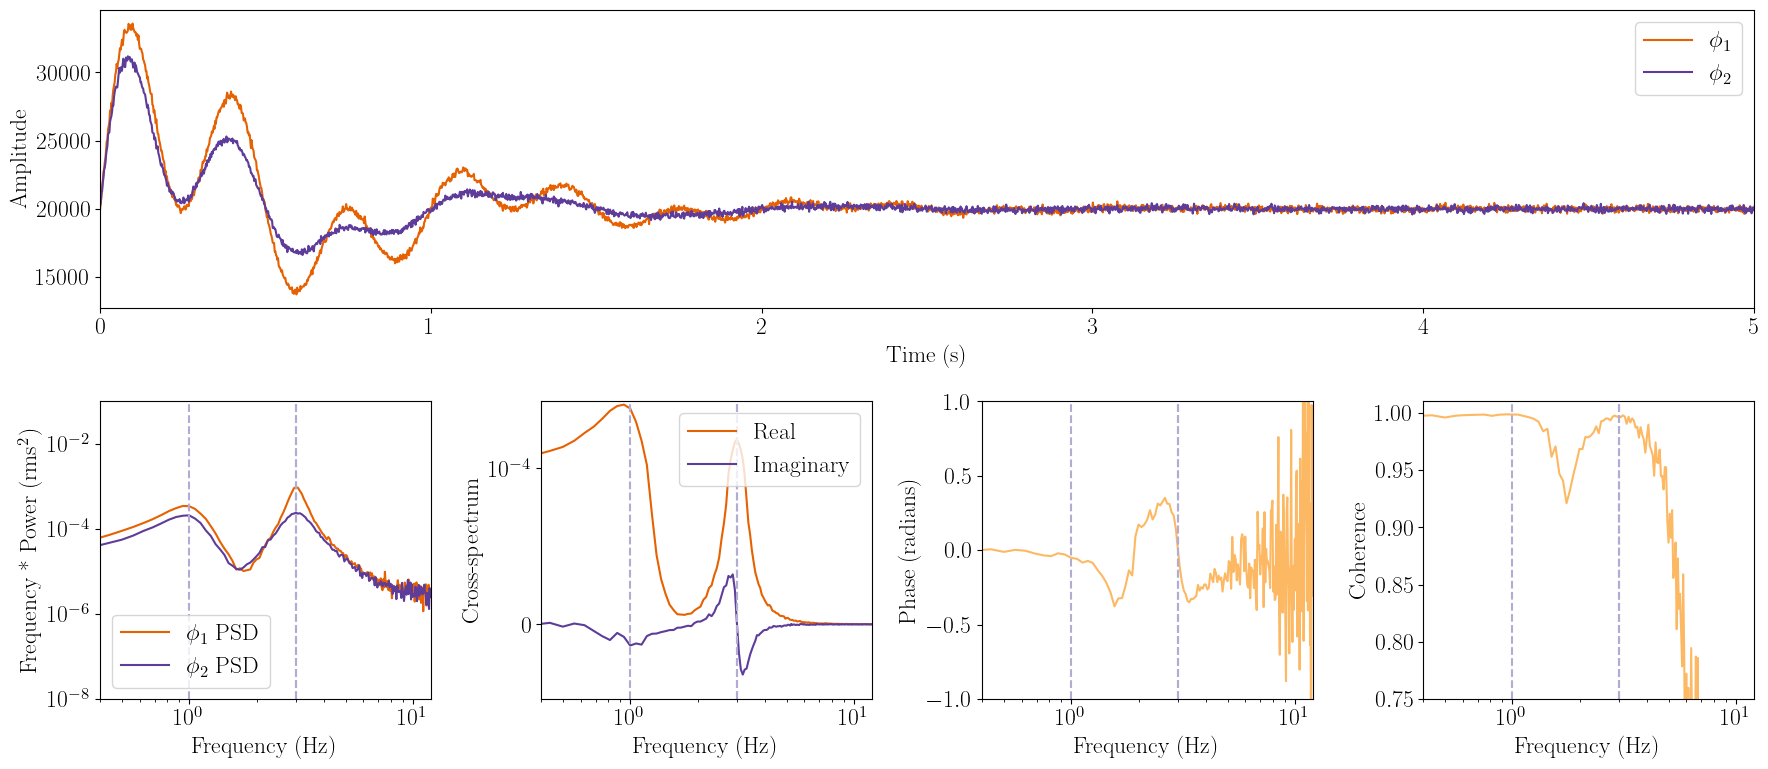

In [4]:
##
dt = 2e-3
T = 16*10
t = np.arange(0, T, dt)

constant = 10000
omega1 = 1.0
omega2 = 3.0
omega3 = 2.99
dampen1 = 0.5
dampen2 = 0.5
dampen3 = 1

x1 = make_decaying_sine(constant, 1, omega1, dampen1, 0, t)
x1_2 = make_decaying_sine(constant, 0.75, omega1, dampen1, 0, t)
x2 = make_decaying_sine(constant, 1, omega2, dampen2, 0, t)
x3 = make_decaying_sine(constant, 1, omega3, dampen3, 0, t)
lc1 = Lightcurve(t, x1)
lc1_2 = Lightcurve(t, x1_2)
lc2 = Lightcurve(t, x2)
lc3 = Lightcurve(t, x3)
x1_noise = lc1+lc2
x2_noise = lc1_2+lc3
x1_noise.counts = np.random.poisson(x1_noise.counts)
x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = AveragedPowerspectrum.from_lightcurve(x1_noise, norm="frac", segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(x2_noise, norm="frac", segment_size=16)

avgcs12 = AveragedCrossspectrum.from_lightcurve(x2_noise, x1_noise, segment_size=16, norm="frac")

plot(t,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=0.4,x_lim_upper=12,file="figures/dual_signal.png",omega3=omega3)


# Broadband dual components

In [5]:
from scipy.signal import butter

def lorentz(freq,peak_f,q,rms):
    par_array = np.array([peak_f,q,rms])
    model = ndspec.Models.lorentz(freq,par_array)
    return model

def low_pass_ar_filter(signal, cutoff_fraction=0.01):
    """
    cutoff_fraction: Lower values = more high-frequency suppression.
    Try 0.05 to 0.01 to see the high-frequency Lorentzian drop.
    """
    # phi is the 'memory' coefficient
    phi = 1 - cutoff_fraction
    filtered = np.zeros_like(signal)
    
    # Simple recursive smoothing
    for i in range(1, len(signal)):
        filtered[i] = phi * filtered[i-1] + (1 - phi) * signal[i]
        
    return filtered

def butterworth_time_domain(signal, fs, cutoff, order=2):
    # 1. Get the Butterworth coefficients
    # 'fs' is your sampling frequency, 'cutoff' is where you want the drop to start
    b, a = butter(order, cutoff, fs=fs, btype='low')
    
    # 2. Initialize the output array
    y = np.zeros_like(signal)
    
    # 3. Apply the difference equation (Time Domain)
    # We start at index 2 because we need two previous values
    for n in range(2, len(signal)):
        y[n] = (b[0]*signal[n] + b[1]*signal[n-1] + b[2]*signal[n-2] 
                - a[1]*y[n-1] - a[2]*y[n-2])
        
    return y

def gaussian_filter(signal, sigma=1):
    """
    Applies a Gaussian filter to the input signal.

    Parameters
    ----------
    signal: array-like
        The input signal to which the Gaussian filter will be applied.
    sigma: float
        The standard deviation of the Gaussian kernel.

    Returns
    -------
    filtered: array-like
        The filtered signal.
    """
    # Create a Gaussian kernel
    kernel = np.exp(-0.5 * (np.arange(-3*sigma, 3*sigma+1) / sigma)**2)
    kernel /= np.sum(kernel)

    # Apply the Gaussian filter using convolution
    filtered = np.convolve(signal, kernel, mode='same')
    return filtered

def resonant_filter(signal, fs, target_freq, Q, gain=1.0):
    """
    Transforms a lightcurve by shifting its Lorentzian peak.
    
    fs: Sampling frequency (Hz)
    target_freq: Where you want the RED peak to be (Hz)
    Q: Quality factor (lower = wider/worse Q)
    gain: Vertical scaling (to drop the PSD height)
    """
    n = len(signal)
    filtered = np.zeros(n)
    
    # 1. Calculate the Bandwidth from Q
    # As Q gets smaller, the bandwidth (bw) gets larger, smearing the signal.
    bw = target_freq / Q
    
    # 2. Determine the Pole Radius (R) and Angle (theta)
    # R determines how "sharp" the peak is.
    R = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * target_freq / fs
    
    # 3. Filter Coefficients
    a1 = 2 * R * np.cos(theta)
    a2 = -R**2
    # Normalization factor to keep the gain in check
    b0 = (1 - R**2) * gain 
    
    # 4. Difference Equation (The Time-Domain Loop)
    for i in range(2, n):
        filtered[i] = (a1 * filtered[i-1] + 
                       a2 * filtered[i-2] + 
                       b0 * signal[i])
        
    return filtered

def frequency_up_conversion(t, x, fshift):
    """
    Upsamples the input signal by a factor of 2 using zero-order hold.

    Parameters
    ----------
    t : array-like
        The time array corresponding to the input signal.
    x : array-like
        The input signal to be upsampled.
    fshift : float
        Frequency shift.

    Returns
    -------
    upsampled : array-like
        The upsampled signal.
    """
    y = x * np.cos(2 * np.pi * fshift * t)
    #y = low_pass_ar_filter(y)
    return y

def timmer_koenig(x, mean, dt, omega1, omega2, q1, q2, rms1, rms2):
    rms = rms1 + rms2
    sim = simulator.Simulator(N=len(x), mean=mean, dt=dt, rms=rms, poisson=True)
    w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
    lorentz1 = lorentz(w,omega1,q1,rms1)
    lorentz2 = lorentz(w,omega2,q2,rms2)
    psd_array = lorentz1 + lorentz2
    psd_err = np.sqrt(psd_array)
    lc1 = sim.simulate(lorentz1)
    lc2 = sim.simulate(lorentz2)
    return lc1, lc2, w, lorentz1, lorentz2, psd_array, psd_err

def plot_2(t_plot,x1_noise,x2_noise,ps1,ps2,avgcs12,x_lim_lower=None,x_lim_upper=None,omega1=None,omega2=None,
           lorentz1=None,lorentz2=None):
    """
    Plots results

    Parameters
    -----------
    t_plot : array
        Time array for the plot.
    x1_noise : Lightcurve
        Lightcurve object for the first signal with noise.
    x2_noise : Lightcurve
        Lightcurve object for the second signal with noise.
    ps1 : Powerspectrum
        Power spectrum object for the first signal.
    ps2 : Powerspectrum
        Power spectrum object for the second signal.
    omega1 : float
        Frequency of the first signal.
    omega2 : float
        Frequency of the second signal.
    cs12 : Crossspectrum
        Cross spectrum object between the two signals.
    avgcs12 : AveragedCrossspectrum
        Averaged cross spectrum object between the two signals.
    x_lim_lower : float
        Lower limit for the x-axis.
    x_lim_upper : float
        Upper limit for the x-axis.

    """
    fig = plt.figure(figsize=(16, 6))

    ax2=plt.subplot(1,4,1)
    ax2.plot(ps1.freq, ps1.freq*ps1.power, c="#e66101",label=r"$\phi_1$")
    ax2.plot(ps2.freq, ps2.freq*ps2.power, c="#5e3c99",label=r"$\phi_2$")
    if omega1 is not None:
        ax2.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax2.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.legend()
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel(r"Frequency * Power (rms$^2$)")
    ax2.set_ylim(5e-5, 1e-1)
    ax2.set_xlim(x_lim_lower, x_lim_upper)

    ax3=plt.subplot(1,4,2)
    ax3.plot(avgcs12.freq, np.real(avgcs12.power), c="#e66101",label="Real")
    ax3.plot(avgcs12.freq, np.imag(avgcs12.power), c="#5e3c99",label="Imaginary")
    if omega1 is not None:
        ax3.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax3.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax3.set_yscale('symlog',linthresh=1e-4)
    ax3.set_xscale("log")
    ax3.set_ylabel('Cross-spectrum')
    ax3.legend()
    #ax3.set_ylim(-1e5, 1e6)
    ax3.set_xlim(x_lim_lower, x_lim_upper)
    ax3.set_xlabel("Frequency (Hz)")

    ax4 = plt.subplot(1,4,3)
    ax4.plot(avgcs12.freq, np.angle(avgcs12.power), c="#fdb863", label=r"$\phi_1/\phi_2$")
    if omega1 is not None:
        ax4.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax4.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")

    ax4.set_xscale("log")
    ax4.set_ylabel('Phase (radians)')
    #ax4.set_ylim(-np.pi, np.pi)
    ax4.set_xlabel("Frequency (Hz)")
    ax4.set_xlim(x_lim_lower, x_lim_upper)
    ax4.legend()

    ax5 = plt.subplot(1,4,4)
    ax5.plot(avgcs12.freq, avgcs12.coherence()[0], c="#fdb863", label=r"$\phi_1/\phi_2$")
    if omega1 is not None:
        ax5.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax5.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax5.set_xscale("log")
    ax5.set_ylabel('Coherence')
    ax5.set_xlabel("Frequency (Hz)")
    ax5.set_ylim(0.8, 1.01)
    ax5.set_xlim(x_lim_lower, x_lim_upper)
    ax5.legend()

    plt.tight_layout()
    plt.savefig("figures/broadband.png")
    plt.show()

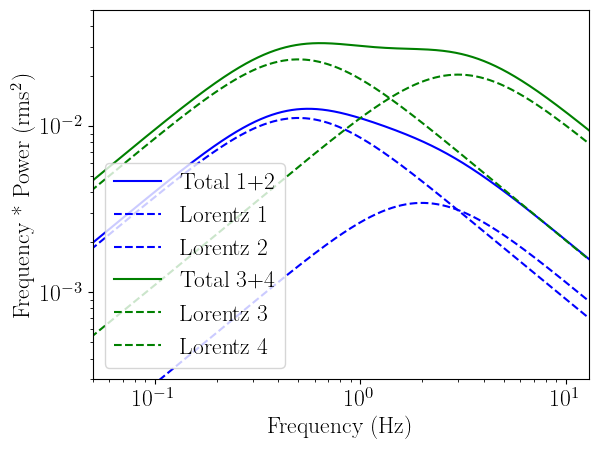

50it [00:00, 12339.09it/s]
50it [00:00, 14286.75it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
50it [00:00, 7119.61it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coherence)) / (np.sqrt(coherence) * n_ave**0.5)


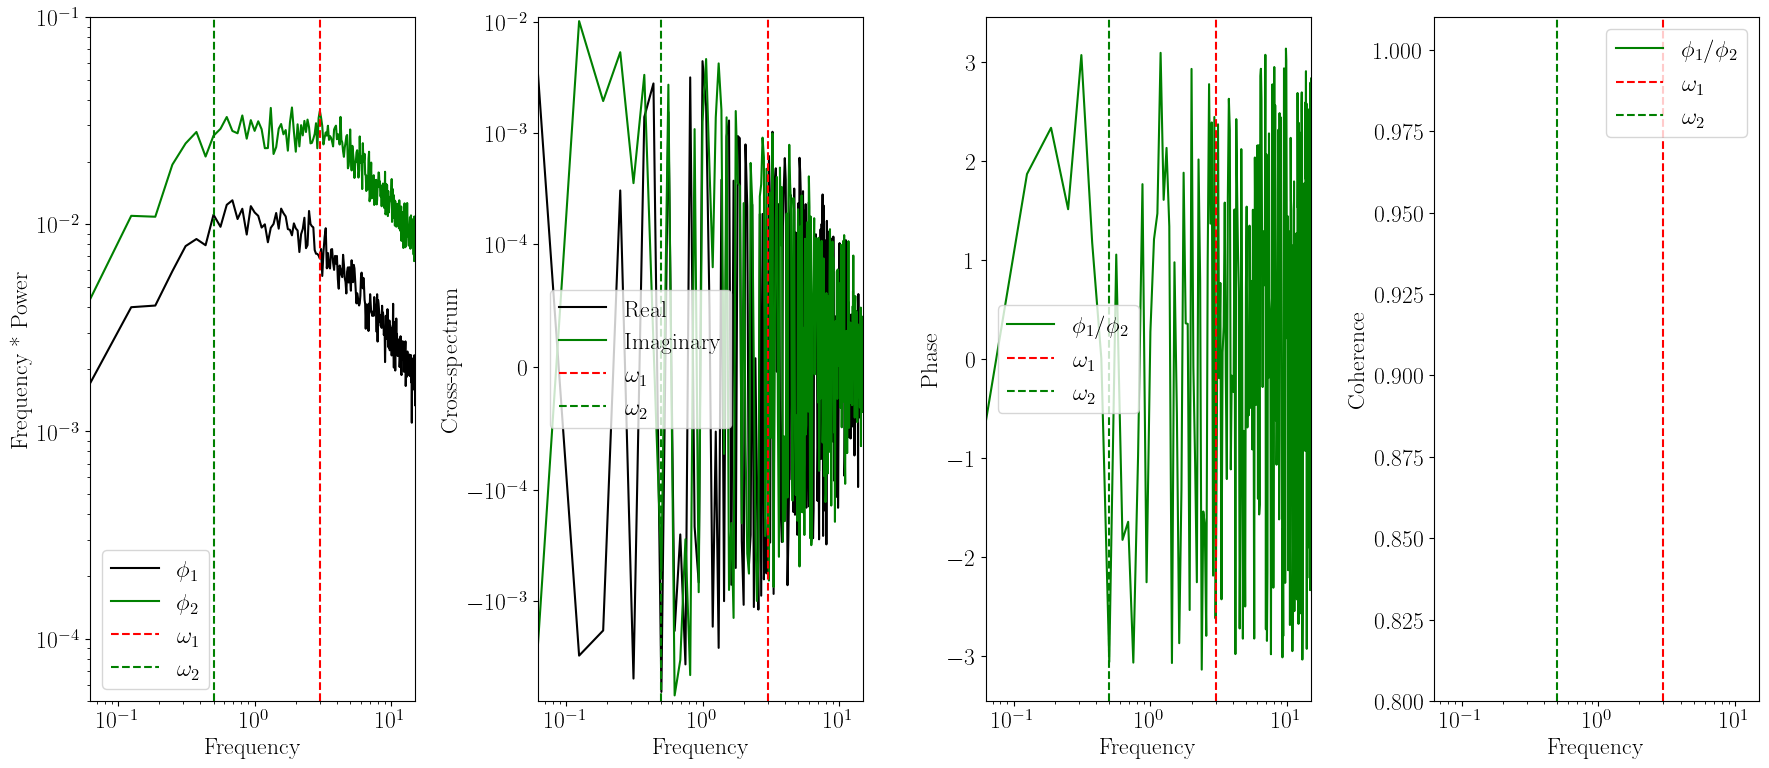

In [ ]:
dt = 2e-3
T = 16*50
t = np.arange(0, T, dt)

lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=1e-1, rms1=0.18, rms2=0.1)
lc3, lc4, w, lorentz3, lorentz4, psd_array2, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=3.0, q1=1e-1, q2=1e-1, rms1=0.3*0.9, rms2=0.27*0.9)

plt.plot(w, w*psd_array1, label= "Total 1+2", c="blue")
plt.plot(w, w*lorentz1, label= "Lorentz 1", ls="--", c="blue")
plt.plot(w, w*lorentz2, label= "Lorentz 2", ls="--", c="blue")
plt.plot(w, w*psd_array2, label= "Total 3+4", c="green")
plt.plot(w, w*lorentz3, label= "Lorentz 3", ls="--", c="green")
plt.plot(w, w*lorentz4, label= "Lorentz 4", ls="--", c="green")
plt.loglog()
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Frequency * Power (rms$^2$)")
plt.xlim(0.05,13)
plt.ylim(3e-4,5e-2)
plt.show()
plt.close()
"""
x1 = gaussian_filter(lc1.counts, sigma=100)
x2 = gaussian_filter(lc2.counts, sigma=100)
x3 = gaussian_filter(lc1.counts + lc2.counts, sigma=100)
print(type(x3))
lc3 = Lightcurve(t, x3)

x4 = butterworth_time_domain(lc2.counts, fs=1.5, cutoff=0.1,order=2)
print(type(x4))
x4[x4 < 0] = 0
lc4 = Lightcurve(t, x4)

x5 = resonant_filter(lc2.counts, fs=3, target_freq=1.5, Q=2, gain=10)
x5[x5 < 0] = 0
print(type(x5))
lc5 = Lightcurve(t, x5)

x6 = frequency_up_conversion(t, lc2.counts, fshift=1.5)
x6[x6 < 0] = 0
lc6 = Lightcurve(t, x6)
"""

lc12 = lc1 + lc2
lc13 = lc3 + lc4

ps1 = AveragedPowerspectrum.from_lightcurve(lc12, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc13, norm="frac",segment_size=16)

cs12 = Crossspectrum.from_lightcurve(lc12, lc13, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc12, lc13, segment_size=16, norm="frac")

plot_2(t,lc12,lc13,ps1,ps2,avgcs12,x_lim_lower=1/16,x_lim_upper=15,omega1=3,omega2=0.5)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sos_signal(t, psd, freqs, N, fudge=1.0):
    # 2. Cumulative Power (Integration)
    cum_power = np.cumsum(psd) * (freqs[1] - freqs[0])
    total_power = cum_power[-1]
    
    # 3. Equal-Area Discretization
    # We find frequencies that split the total power into N equal chunks
    target_levels = np.linspace(0, total_power, N + 1)
    chosen_freqs = []
    for i in range(N):
        # Find frequency where cumulative power hits the midpoint of the chunk
        midpoint = (target_levels[i] + target_levels[i+1]) / 2
        idx = np.argmin(np.abs(cum_power - midpoint))
        chosen_freqs.append(freqs[idx])
        
    # 4. Synthesize Signal
    # Amplitude for equal-area: A = sqrt(2 * total_power / N)
    amp = np.sqrt(2 * total_power / N) / fudge
    signal = np.zeros_like(t)
    alpha = 0.1
    for f in chosen_freqs:
        signal += amp * np.cos(2 * np.pi * f * t) * np.exp(-alpha * np.abs(t))

    return t, signal, chosen_freqs

dt = 2e-3
T = 16*100
t = np.arange(0, T, dt)

lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=1e-1, rms1=0.18, rms2=0.1)
lc3, lc4, w, lorentz3, lorentz4, psd_array2, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=3.0, q1=1e-1, q2=1e-1, rms1=0.3*0.9, rms2=0.4)

# Parameters
N_waves = 5000  # Try 15 vs 100 to see the difference
t, sig, f_list = generate_sos_signal(t, lorentz1+lorentz2, w, N_waves, 0.9)
sig = constant*sig + constant
#sig[sig < 0] = 0
#sig = np.random.poisson(sig)
lc_approx = Lightcurve(t,sig)
print(f"Approximated using only {len(f_list)} sine waves.")

t2, sig2, f_list2 = generate_sos_signal(t, lorentz3+lorentz4, w, N_waves,0.6)
sig2 = constant*sig2 + constant
#sig2[sig2 < 0] = 0
#sig2 = np.random.poisson(sig2)
lc_approx2 = Lightcurve(t2,sig2)
print(f"Approximated using only {len(f_list2)} sine waves.")

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")


Approximated using only 5000 sine waves.
Approximated using only 5000 sine waves.


100it [00:00, 8453.19it/s]
100it [00:00, 12730.84it/s]


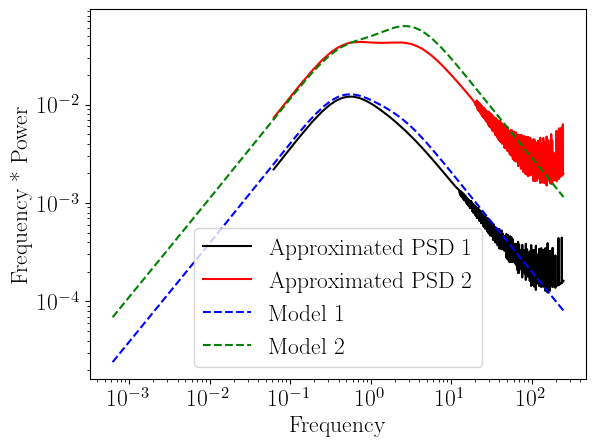

In [7]:
ps1 = AveragedPowerspectrum.from_lightcurve(lc_approx, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc_approx2, norm="frac",segment_size=16)

plt.plot(ps1.freq, ps1.freq*ps1.power, 'k-',label=r"Approximated PSD 1")
plt.plot(ps2.freq, ps2.freq*ps2.power, 'r-',label=r"Approximated PSD 2")
plt.plot(w, w*(lorentz1+lorentz2), 'b--',label=r"Model 1")
plt.plot(w, w*(lorentz3+lorentz4), 'g--',label=r"Model 2")
plt.xlabel("Frequency")
plt.ylabel("Frequency * Power")
plt.loglog()
plt.legend()
plt.show()

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
100it [00:00, 6997.50it/s]


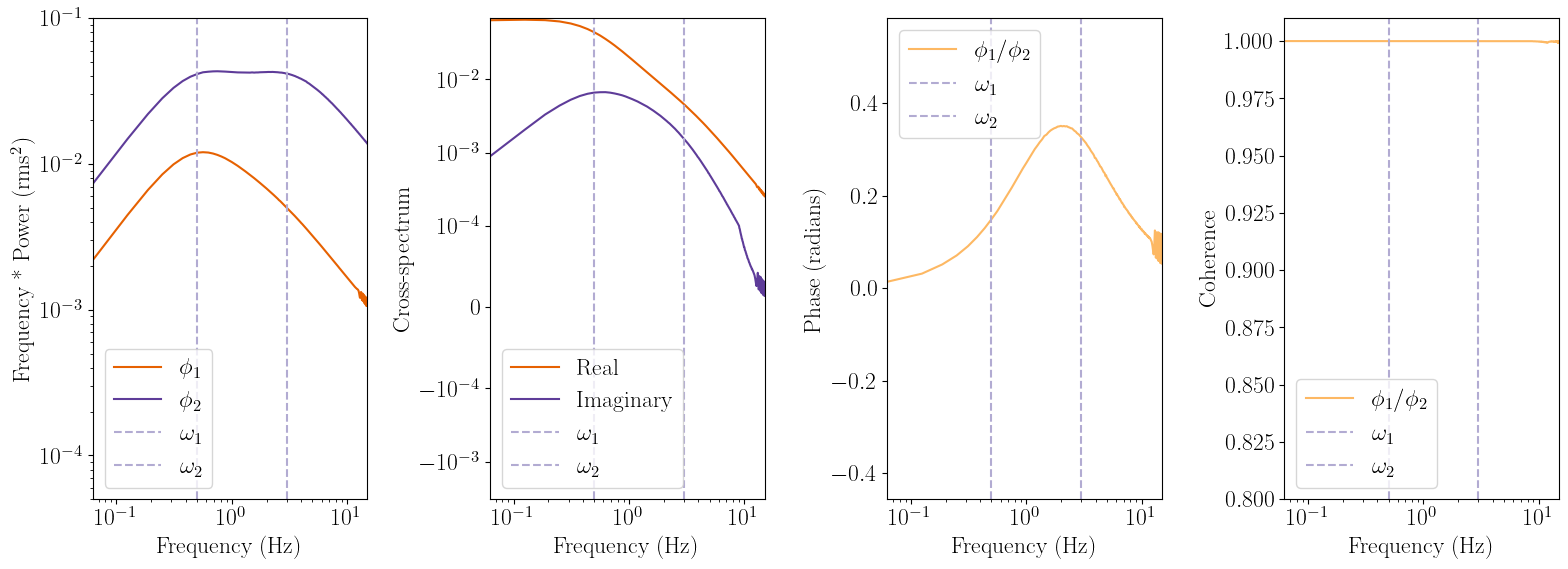

In [8]:
cs12 = Crossspectrum.from_lightcurve(lc_approx, lc_approx2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc_approx, lc_approx2, segment_size=16, norm="frac")

plot_2(t,lc_approx,lc_approx2,ps1,ps2,avgcs12,x_lim_lower=1/16,x_lim_upper=15,omega1=3,omega2=0.5)